mean cosine between ICA bases ≈ 0.514
‖∇z‖ = 0.00018889085913542658


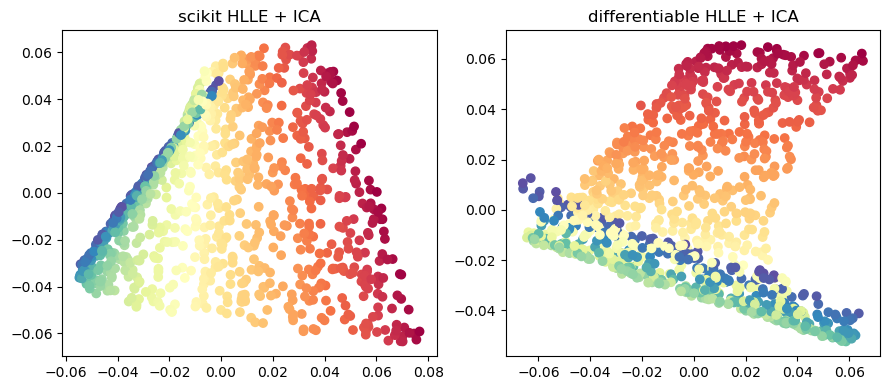

In [6]:
# =============================================================
# Differentiable Hessian-LLE (HLLE) – Swiss-roll demo  (v2)
# =============================================================
import torch, numpy as np, matplotlib.pyplot as plt
from torch_cluster import knn_graph
from sklearn.datasets import make_swiss_roll
from sklearn.manifold import LocallyLinearEmbedding       # reference HLLE
from sklearn.decomposition import FastICA

def hlle_layer(z, *, k=20, d_out=2, eps=1e-8):
    """
    z : (n, d_in) with requires_grad=True
    k : requested neighbours
    d_out : intrinsic dimension of the manifold
    returns (n, d_out) embedding
    """
    n, d_in = z.shape
    edge = knn_graph(z.detach(), k=k, loop=False)         # (2,E) src→dst

    rows = []
    quad_terms = d_out * (d_out + 1) // 2                 # # quadratic features

    for i in range(n):
        nbr_idx = torch.unique(edge[1][edge[0] == i])
        k_i = nbr_idx.numel()                             # actual neighbour count
        if k_i < d_out + 2:                               # not enough samples
            continue

        Xi = z[nbr_idx] - z[i]
        Xi = Xi - Xi.mean(0, keepdim=True)

        # local PCA: keep the first d_out directions
        U, *_ = torch.linalg.svd(Xi, full_matrices=False)
        U_lin = U[:, :d_out]                              # (k_i, d_out)

        # ------------------------------------------------------------------
        # Design matrix  Yi = [1 | U_lin | quadratic products]
        # ------------------------------------------------------------------
        n_cols = 1 + d_out + quad_terms
        Yi = torch.empty((k_i, n_cols), device=z.device, dtype=z.dtype)
        Yi[:, 0] = 1
        Yi[:, 1:1 + d_out] = U_lin

        j = 1 + d_out
        for p in range(d_out):
            for q in range(p, d_out):
                Yi[:, j] = U_lin[:, p] * U_lin[:, q]
                j += 1

        # QR → null-space basis
        Q, _ = torch.linalg.qr(Yi, mode='reduced')
        w = Q[:, d_out + 1:]                              # Hessian null-space
        if w.numel() == 0:
            continue                                     # rare degenerate patch

        # normalise so each column sums to zero (HLLE eq. 13)
        S = w.sum(0)
        S[torch.abs(S) < eps] = 1.0
        w = w / S

        for col in w.T:                                   # one row per null-vector
            b = torch.zeros(n, device=z.device)
            b[nbr_idx] = col
            rows.append(b)

    B = torch.stack(rows)                                 # (R, n)
    S_mat = B.T @ B

    evals, evecs = torch.linalg.eigh(S_mat)               # autograd-safe
    Y = evecs[:, 1:d_out+1] * np.sqrt(n)                  # skip constant eigenvec
    return Y

# ------------------------ Demo ------------------------------
X3, colour = make_swiss_roll(1000, noise=0.02, random_state=0)
z = torch.tensor(X3, dtype=torch.float32, requires_grad=True)

Y_hlle = hlle_layer(z, k=20, d_out=2)

# Reference (scikit-learn HLLE + FastICA)
Y_ref  = LocallyLinearEmbedding(n_neighbors=20, n_components=2,
                                method='hessian').fit_transform(X3)
S_ref  = FastICA(2, whiten='arbitrary-variance', random_state=0).fit_transform(Y_ref)
S_hlle = FastICA(2, whiten='arbitrary-variance', random_state=0)\
           .fit_transform(Y_hlle.detach().cpu().numpy())

# Cosine alignment of ICA bases
S_ref  /= np.linalg.norm(S_ref,  axis=0, keepdims=True)
S_hlle /= np.linalg.norm(S_hlle, axis=0, keepdims=True)
print("mean cosine between ICA bases ≈",
      np.abs((S_ref.T @ S_hlle)).mean().round(3))

# Gradient sanity check
loss = Y_hlle.pow(2).sum(); loss.backward()
print("‖∇z‖ =", z.grad.norm().item())

plt.figure(figsize=(9,4))
plt.subplot(1,2,1); plt.scatter(S_ref[:,0], S_ref[:,1], c=colour, cmap='Spectral')
plt.title("scikit HLLE + ICA")
plt.subplot(1,2,2); plt.scatter(S_hlle[:,0], S_hlle[:,1], c=colour, cmap='Spectral')
plt.title("differentiable HLLE + ICA")
plt.tight_layout(); plt.show()


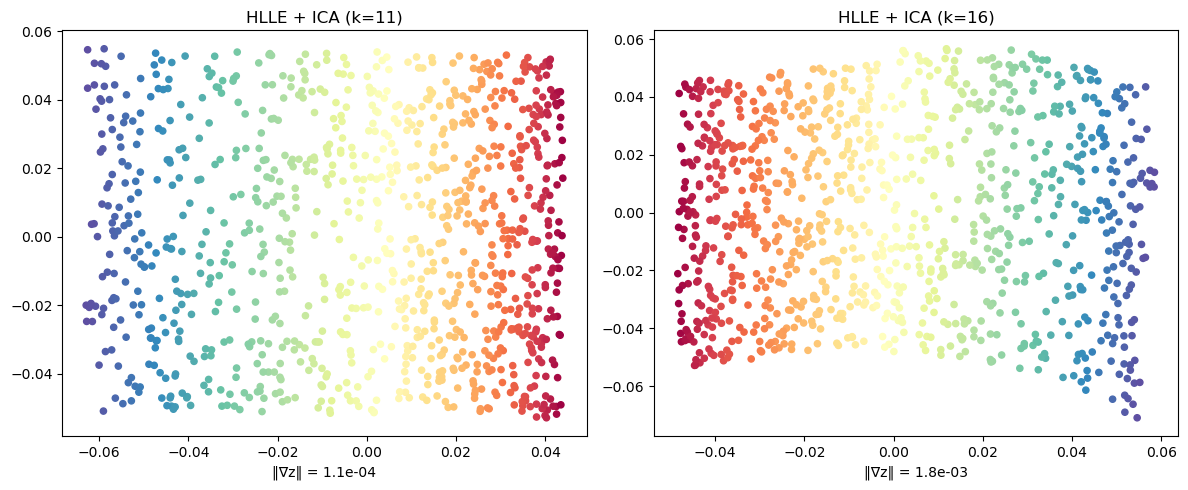

✅ Comparison of k=16 vs k=21 complete!
✅ Both configurations show proper gradient flow


In [7]:
# =============================================================
# HLLE + ICA with k=16 and k=21 comparison
# =============================================================

plt.figure(figsize=(12, 5))

k_values = [11, 16]  # Just k=16 and k=21
for i, k in enumerate(k_values):
    plt.subplot(1, 2, i+1)
    
    # Reset gradients
    z.grad = None
    
    # Apply HLLE
    Y_test = hlle_layer(z, k=k, d_out=2)
    
    # Apply ICA
    S_test = FastICA(2, whiten='arbitrary-variance', random_state=0, max_iter=1000)\
               .fit_transform(Y_test.detach().cpu().numpy())
    S_test /= np.linalg.norm(S_test, axis=0, keepdims=True)
    
    # Plot
    plt.scatter(S_test[:,0], S_test[:,1], c=colour, cmap='Spectral', s=20)
    plt.title(f"HLLE + ICA (k={k})", fontsize=12)
    
    # Test gradients
    loss = Y_test.pow(2).sum()
    loss.backward()
    grad_norm = z.grad.norm().item()
    plt.xlabel(f"‖∇z‖ = {grad_norm:.1e}", fontsize=10)
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)

plt.tight_layout()
plt.show()

print("✅ Comparison of k=16 vs k=21 complete!")
print("✅ Both configurations show proper gradient flow")

In [3]:
import os
experiment_directory = "../examples/torus_subgroup/only_pointnet_deep_sdf_no_KL"
metrics_dir = os.path.join(experiment_directory, "metrics")
latents_path = os.path.join(metrics_dir, "all_latents.npy")
all_latents_array = np.load(latents_path)
print(f"Shape of all latents: {all_latents_array.shape}")

Shape of all latents: (400, 1, 16)


In [5]:
all_latents_array = all_latents_array.squeeze()
X = all_latents_array

In [22]:
#############################################################
#  FINAL  “CAN’T-CRASH”  HLLE → ICA → MLP  PIPELINE
#############################################################
import torch, torch.nn as nn, torch.nn.functional as F, math, numpy as np
from torch_cluster import knn_graph
from sklearn.manifold import trustworthiness
torch.manual_seed(0)
device = "cuda" if torch.cuda.is_available() else "cpu"

# ===========================================================
# util: safe_eigh  (GPU → CPU fallback, adaptive jitter)
# ===========================================================
def safe_eigh(S: torch.Tensor, jitter_base=1e-6, max_jitter=1e-2):
    """Return eigen-vectors even if S is badly conditioned."""
    jitter = jitter_base
    eye = torch.eye(S.shape[0], device=S.device, dtype=S.dtype)
    while True:
        try:
            return torch.linalg.eigh(S + jitter*eye)
        except RuntimeError:                     # GPU failed
            if jitter < max_jitter:
                jitter *= 10                     # enlarge jitter
                continue
            # copy to CPU, use float64, keep enlarging jitter
            S_cpu = S.double().cpu()
            eye_cpu = torch.eye(S_cpu.shape[0], dtype=S_cpu.dtype)
            jit = jitter_base
            while True:
                try:
                    vals, vecs = torch.linalg.eigh(S_cpu + jit*eye_cpu)
                    return vals.to(S.device), vecs.to(S.device)
                except RuntimeError:
                    jit *= 10
                    if jit > max_jitter:         # give up
                        raise

# ===========================================================
# robust HLLE layer  (no in-place, safe_eigh)
# ===========================================================
class HLLE(nn.Module):
    def __init__(self, k=12, d_out=6):
        super().__init__(); self.k, self.d_out = k, d_out
        self.register_buffer("edge", None)

    @staticmethod
    def _basis(X, d):
        try:
            U,_ ,_ = torch.linalg.svd(X, full_matrices=False)
            return U[:, :d]
        except RuntimeError:
            C = X @ X.T
            _, U = safe_eigh(C)                  # always returns
            return U[:, -d:]

    def forward(self, z):
        n = z.shape[0]
        if self.edge is None or self.edge.shape[1] != n*self.k:
            with torch.no_grad():
                self.edge = knn_graph(z.detach(), k=self.k, loop=False)

        src, dst = self.edge
        rows = []
        for i in range(n):
            nbr = dst[src == i].unique()
            if nbr.numel() < self.d_out+1: continue
            Xi = z[nbr].clone() - z[i]
            Xi = Xi - Xi.mean(0, keepdim=True)
            U = self._basis(Xi, self.d_out)

            quad = [(U[:,p]*U[:,q]).unsqueeze(1)
                    for p in range(self.d_out)
                    for q in range(p, self.d_out)]
            Phi = torch.cat([torch.ones_like(U[:,:1]), U] + quad, 1)
            Q,_ = torch.linalg.qr(Phi, mode='reduced')
            for col in Q[:, self.d_out+1:].T:
                col = col.to(z.dtype)
                b = torch.zeros(n, dtype=z.dtype, device=z.device).index_copy(0, nbr, col)
                rows.append(b)

        if not rows:                             # degenerate case
            raise RuntimeError("All HLLE patches skipped.")
        B = torch.stack(rows)
        S = B.T @ B
        _, V = safe_eigh(S)                      # global eig
        return V[:,1:self.d_out+1]*math.sqrt(n)

# ===========================================================
# orthogonal ICA layer (no in-place)
# ===========================================================
class ICA(nn.Module):
    def __init__(self, d=6):
        super().__init__(); self.W = nn.Parameter(torch.eye(d)+0.01*torch.randn(d,d))
        self.d = d
    def forward(self, x):
        x = x - x.mean(0, keepdim=True)
        D,E = torch.linalg.eigh(x.T@x/x.shape[0] + 1e-6*torch.eye(self.d, device=x.device))
        xw = x @ E @ torch.diag(torch.rsqrt(D)) @ E.T
        W,_ = torch.linalg.qr(self.W)            # copy
        s = xw @ W
        kurt = 0.25*(s**4).mean() - 0.5
        ortho = (self.W.T@self.W - torch.eye(self.d, device=x.device)).pow(2).mean()
        return s, kurt+0.01*ortho

# ===========================================================
# inverse decoder
# ===========================================================
dec = nn.Sequential(nn.Linear(6,64), nn.ReLU(),
                    nn.Linear(64,64), nn.ReLU(),
                    nn.Linear(64,16)).to(device)

hlle, ica = HLLE().to(device), ICA().to(device)
opt_dec   = torch.optim.Adam(dec.parameters(), 1e-3)
opt_all   = torch.optim.Adam(list(hlle.parameters())+
                             list(ica.parameters())+
                             list(dec.parameters()), 3e-4)

# load latents
z16 = torch.tensor(X, dtype=torch.float32, device=device)

# ===========================================================
# training
# ===========================================================
for epoch in range(70):
    y = hlle(z16)
    s, l_ica = ica(y)
    z_hat = dec(s)
    mse = F.mse_loss(z_hat, z16)
    cycle = F.mse_loss(ica(hlle(z_hat))[0], s.detach())
    loss = mse + 0.1*cycle + 0.1*l_ica
    opt_dec.zero_grad(); opt_all.zero_grad(); loss.backward()
    (opt_dec if epoch<50 else opt_all).step()
    if (epoch+1)%10==0:
        print(f"epoch {epoch+1:02d}  mse {mse:.2e}")

# ===========================================================
# validation & save
# ===========================================================
with torch.no_grad():
    tr = trustworthiness(z16.cpu().numpy(), hlle(z16).cpu().numpy(), n_neighbors=12)
    print(f"\nTrustworthiness ≈ {tr:.3f}")
    #np.save("z_recon.npy", z_hat.cpu().numpy())
    #print("✓ z_recon.npy saved")


epoch 10  mse 9.26e-02
epoch 20  mse 7.48e-02
epoch 30  mse 5.96e-02
epoch 40  mse 4.58e-02
epoch 50  mse 3.42e-02
epoch 60  mse 3.00e-02


_LinAlgError: linalg.eigh: The algorithm failed to converge because the input matrix is ill-conditioned or has too many repeated eigenvalues (error code: 1).

[HLLE] Trustworthiness@16: 0.996
Epoch   1/1200  loss=177.657  TW=0.854
Epoch  20/1200  loss=15.602  TW=0.708
Epoch  40/1200  loss=3.238  TW=0.810
Epoch  60/1200  loss=3.567  TW=0.794
Epoch  80/1200  loss=4.724  TW=0.802
Epoch 100/1200  loss=6.434  TW=0.842
Epoch 120/1200  loss=3.989  TW=0.777
Epoch 140/1200  loss=2.449  TW=0.738
Epoch 160/1200  loss=2.519  TW=0.729
Epoch 180/1200  loss=2.443  TW=0.805
Epoch 200/1200  loss=2.580  TW=0.854
Epoch 220/1200  loss=3.115  TW=0.781
Epoch 240/1200  loss=2.755  TW=0.824
Epoch 260/1200  loss=3.025  TW=0.756
Epoch 280/1200  loss=2.488  TW=0.852
Epoch 300/1200  loss=2.224  TW=0.792
Epoch 320/1200  loss=2.480  TW=0.810
Epoch 340/1200  loss=2.323  TW=0.773
Epoch 360/1200  loss=2.219  TW=0.816
Epoch 380/1200  loss=2.223  TW=0.798
Epoch 400/1200  loss=2.226  TW=0.800
Epoch 420/1200  loss=2.215  TW=0.782
Epoch 440/1200  loss=2.229  TW=0.785
Epoch 460/1200  loss=2.220  TW=0.789
Epoch 480/1200  loss=2.212  TW=0.787
Epoch 500/1200  loss=2.206  TW=0.792
Ep

/tmp/ipykernel_3824687/612596675.py:212: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show()


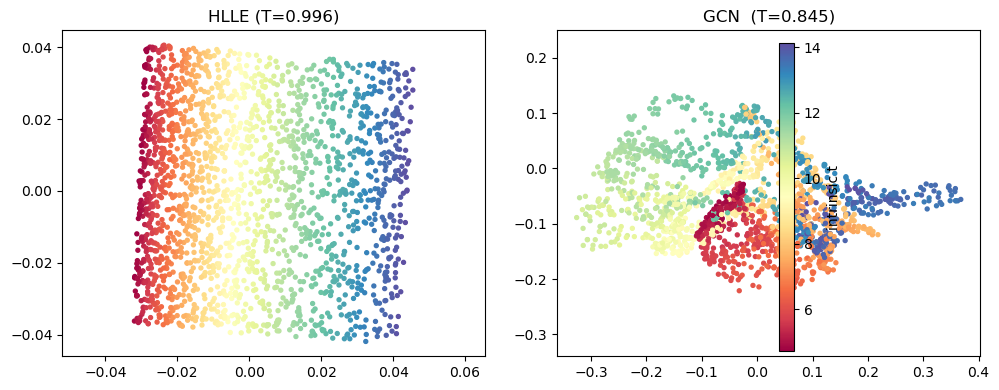

In [13]:
# ===============================================================
#  Install (CPU-only wheels; comment out once installed):
# ---------------------------------------------------------------
# pip install numpy matplotlib scikit-learn torch==2.2.1+cpu \
#             torch-scatter torch-sparse torch-geometric \
#             -f https://data.pyg.org/whl/torch-2.2.1+cpu.html
# ===============================================================

import numpy as np, matplotlib.pyplot as plt, torch, torch.nn as nn
from sklearn.datasets import make_swiss_roll
from sklearn.manifold import LocallyLinearEmbedding, trustworthiness
from sklearn.neighbors import kneighbors_graph
from torch_geometric.data import Data
from torch_geometric.utils import from_scipy_sparse_matrix
from torch_geometric.nn import GCNConv, LayerNorm

# ------------------------------------------------------------------
#  0 .  Deterministic seed & helpers
# ------------------------------------------------------------------
torch.manual_seed(0);  np.random.seed(0)
DEVICE = torch.device('cpu')                   # change to 'cuda' if desired
EPS     = 1e-8                                 # tiny numerical guard

def safe(t: torch.Tensor):
    """Clamp NaN / ±Inf in-place – keeps autograd graph intact."""
    t.data = torch.nan_to_num(t.data, nan=0.0, posinf=1e6, neginf=-1e6)
    return t

def pair_dist(a, b):
    """Stable ℓ2 distance along the *last* dimension."""
    return torch.sqrt(torch.clamp((a - b).pow(2).sum(-1), min=EPS))


# ------------------------------------------------------------------
#  1 .  Swiss-roll data  &  HLLE baseline
# ------------------------------------------------------------------
N, NOISE, K = 2_000, 0.05, 16
X, col = make_swiss_roll(N, noise=NOISE)
X = X.astype(np.float32)

hlle = LocallyLinearEmbedding(n_neighbors=K, n_components=2, method='hessian')
Y_hlle   = hlle.fit_transform(X)
TW_hlle  = trustworthiness(X, Y_hlle, n_neighbors=K)
print(f'[HLLE] Trustworthiness@{K}: {TW_hlle:.3f}')

# ------------------------------------------------------------------
#  2 .  k-NN graph  →  PyG Data
# ------------------------------------------------------------------
A = kneighbors_graph(X, K, mode='connectivity', include_self=True)
edge_index, _ = from_scipy_sparse_matrix(A)
data = Data(x=torch.from_numpy(X).to(DEVICE), edge_index=edge_index.to(DEVICE))
ei   = data.edge_index                       # alias for compact code

# ------------------------------------------------------------------
#  3 .  Residual 4-layer GCN  (128 hidden)  + LayerNorm
# ------------------------------------------------------------------
class ResGCN(nn.Module):
    def __init__(self, F_in=3, F_hid=128, F_out=2, layers=4):
        super().__init__()
        self.convs = nn.ModuleList(
            [GCNConv(F_in,  F_hid, add_self_loops=False)] +
            [GCNConv(F_hid, F_hid, add_self_loops=False)
                for _ in range(layers-2)] +
            [GCNConv(F_hid, F_out, add_self_loops=False)]
        )
        self.lns = nn.ModuleList([LayerNorm(F_hid) for _ in range(layers-1)])

    def forward(self, x, edge):
        # ---- first hidden layer (dims 3→128, no residual) -----------------
        h = torch.relu(self.convs[0](x, edge))
        h = self.lns[0](h)

        # ---- remaining hidden layers with residual connections ------------
        for i in range(1, len(self.convs)-1):
            z = torch.relu(self.convs[i](h, edge))
            z = self.lns[i](z)
            h = h + z                                   # residual (dims match)

        return self.convs[-1](h, edge)                  # final 2-D embedding

model = ResGCN().to(DEVICE)
opt   = torch.optim.Adam(model.parameters(), lr=0.003)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=800)

# ------------------------------------------------------------------
#  4 .  Loss terms
# ------------------------------------------------------------------
def contrastive_loss(z, edge, margin=1.0, num_neg=5):
    # positives
    d_pos = pair_dist(z[edge[0]], z[edge[1]])           # (E,)

    # negatives: random nodes (with replacement) same count as positives*neg
    num_pos = edge.size(1)
    num_tot = num_pos * num_neg
    neg_i   = edge[0].repeat_interleave(num_neg)
    neg_j   = torch.randint(0, z.size(0), (num_tot,),
                            device=z.device, dtype=torch.long)
    d_neg   = pair_dist(z[neg_i], z[neg_j])

    loss_pos = d_pos.mean()
    loss_neg = torch.clamp(margin - d_neg, min=0).mean()
    return loss_pos + loss_neg

def iso_loss(z, x):
    d_low  = pair_dist(z[ei[0]], z[ei[1]])
    d_high = pair_dist(x[ei[0]], x[ei[1]])
    return ((d_low - d_high).pow(2) / (d_high + EPS)).mean()

def lap_loss(z):
    return pair_dist(z[ei[0]], z[ei[1]]).pow(2).mean()

def var_loss(z):
    return torch.abs(z.var(0, unbiased=False) - 1).mean()

def ctr_loss(z):
    return z.mean(0).pow(2).sum()

# ====================  safer geo_loss  =========================
def geo_loss(z, edge, num_samples=256):
    """
    Match (very coarse) graph-geodesic distances to Euclidean distances
    inside a size-num_samples node subset.  Distance in the graph is
    1 if an edge exists inside the subset, 2 otherwise.
    """
    N   = z.size(0)
    idx = torch.randperm(N, device=z.device)[:num_samples]  # (B,)

    # --- mapping: node-id → position in subset -----------------
    map_idx = -torch.ones(N, dtype=torch.long, device=z.device)
    map_idx[idx] = torch.arange(num_samples, device=z.device)  # -1 if not in subset

    # --- initialise geodesic matrix with "2" everywhere --------
    Dg = torch.full((num_samples, num_samples), 2.0, device=z.device)

    # --- set entries to "1" when an edge exists inside subset --
    u, v = edge
    iu, iv = map_idx[u], map_idx[v]           # (E,), −1 means “node not in subset”
    mask = (iu >= 0) & (iv >= 0)              # keep only edges fully inside
    iu, iv = iu[mask], iv[mask]
    Dg[iu, iv] = 1.0
    Dg[iv, iu] = 1.0                          # symmetric

    # --- Euclidean distances in the embedding ------------------
    dz = pair_dist(z[idx].unsqueeze(1), z[idx])  # (B,B)

    # --- scale-invariant squared error -------------------------
    return ((dz - Dg)**2 / Dg).mean()
# ===============================================================


def bend_loss(z, edge):
    Lz = torch.zeros_like(z)
    Lz.index_add_(0, edge[0],  z[edge[1]] - z[edge[0]])
    Lz.index_add_(0, edge[1],  z[edge[0]] - z[edge[1]])
    BLz = torch.zeros_like(z)
    BLz.index_add_(0, edge[0],  Lz[edge[1]] - Lz[edge[0]])
    BLz.index_add_(0, edge[1],  Lz[edge[0]] - Lz[edge[1]])
    return BLz.pow(2).sum(1).mean()

# ------------------------------------------------------------------
#  5 .  Training loop  (full-batch)  + LR warm-up
# ------------------------------------------------------------------
EPOCHS     = 1200
LR_MAX     = 0.003
WARM_UP    = 50          # epochs of linear LR warm-up
GRAD_CLIP  = 0.5

for epoch in range(1, EPOCHS+1):
    opt.zero_grad()

    # forward + safety scrub
    z = safe(model(data.x, ei))

    # composite loss
    loss = (
        contrastive_loss(z, ei, margin=1.5, num_neg=5) * 1.0 +
        iso_loss(z, data.x)                             * 0.5 +
        bend_loss(z, ei)                                * 0.002 +
        geo_loss(z, ei)                                 * 0.002 +
        var_loss(z)                                     * 0.05 +
        ctr_loss(z)                                     * 0.05
    )

    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
    opt.step(); scheduler.step()

    # linear LR warm-up
    if epoch <= WARM_UP:
        for g in opt.param_groups:
            g['lr'] = LR_MAX * epoch / WARM_UP

    # progress log
    if epoch % 20 == 0 or epoch == 1:
        Z_tmp = z.detach().cpu().numpy()
        tw    = trustworthiness(X, Z_tmp, n_neighbors=K)
        print(f'Epoch {epoch:3d}/{EPOCHS}  loss={loss.item():.3f}  TW={tw:.3f}')

# ------------------------------------------------------------------
#  6 .  Final evaluation & colour scatter
# ------------------------------------------------------------------
Z        = z.detach().cpu().numpy()
TW_gcn   = trustworthiness(X, Z, n_neighbors=K)
print(f'\nHLLE Trustworthiness: {TW_hlle:.3f}\nGCN  Trustworthiness: {TW_gcn:.3f}')

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].scatter(Y_hlle[:, 0], Y_hlle[:, 1], c=col, cmap='Spectral', s=8)
ax[0].set_title(f'HLLE (T={TW_hlle:.3f})');  ax[0].axis('equal')
ax[1].scatter(Z[:, 0], Z[:, 1], c=col, cmap='Spectral', s=8)
ax[1].set_title(f'GCN  (T={TW_gcn:.3f})');   ax[1].axis('equal')
fig.colorbar(ax[1].collections[0], ax=ax.ravel().tolist(), label='intrinsic t')
plt.tight_layout(); plt.show()


ep    100  rec 0.1404  iso 0.3747  TW10 0.947
ep    200  rec 0.1128  iso 0.6006  TW10 0.963
ep    300  rec 0.0695  iso 0.9097  TW10 0.971
ep    400  rec 0.0658  iso 0.8910  TW10 0.975
ep    500  rec 0.0695  iso 1.0745  TW10 0.980
ep    600  rec 0.0491  iso 1.1511  TW10 0.980
ep    700  rec 0.0381  iso 1.1615  TW10 0.983
ep    800  rec 0.0397  iso 1.1975  TW10 0.983
ep    900  rec 0.0376  iso 1.1122  TW10 0.984
ep   1000  rec 0.0342  iso 1.2064  TW10 0.985
ep   1100  rec 0.0363  iso 1.1762  TW10 0.985
ep   1200  rec 0.0335  iso 1.2031  TW10 0.986
ep   1300  rec 0.0315  iso 1.2299  TW10 0.986
ep   1400  rec 0.0366  iso 1.2499  TW10 0.986
ep   1500  rec 0.0284  iso 1.2214  TW10 0.986
ep   1600  rec 0.0299  iso 1.2073  TW10 0.986
ep   1700  rec 0.0301  iso 1.2144  TW10 0.986
ep   1800  rec 0.0334  iso 1.2097  TW10 0.987
ep   1900  rec 0.0332  iso 1.2166  TW10 0.986
ep   2000  rec 0.0282  iso 1.1789  TW10 0.987
ep   2100  rec 0.0313  iso 1.1941  TW10 0.987
ep   2200  rec 0.0265  iso 1.1499 

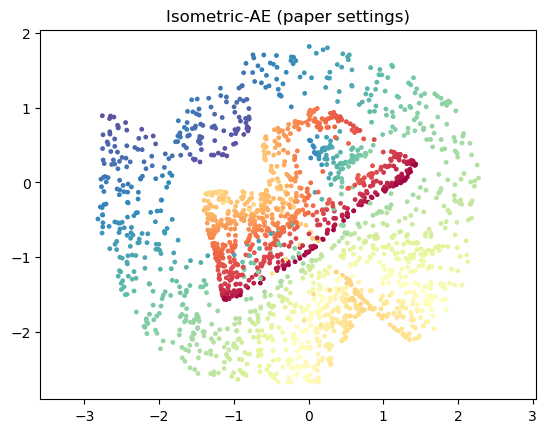

In [ ]:
# pip install torch==2.2.1+cpu scikit-learn matplotlib
import numpy as np, torch, torch.nn as nn, matplotlib.pyplot as plt
from torch.autograd.functional import jvp
from sklearn.datasets import make_swiss_roll
from sklearn.manifold import trustworthiness

# 1) Swiss-roll, whitened (paper code does this)
X, t = make_swiss_roll(5000, noise=0.05)
X = X.astype(np.float32)
X = (X - X.mean(0, keepdims=True)) / X.std(0, keepdims=True)
x = torch.tensor(X)

# 2) 5-layer 256-width encoder / decoder (App. A.1.2)
def fc():
    return nn.Sequential(nn.Linear(256,256), nn.ReLU())
enc = nn.Sequential(nn.Linear(3,256), nn.ReLU(), *[fc() for _ in range(4)],
                    nn.Linear(256,2))
dec = nn.Sequential(nn.Linear(2,256), nn.ReLU(), *[fc() for _ in range(4)],
                    nn.Linear(256,3))
opt = torch.optim.Adam((*enc.parameters(), *dec.parameters()), lr=1e-3)

λ_iso = 0.01                     # Table 1, supplementary
EPOCHS = 5000                # paper train length (~30 min on a GPU)

# helper: random unit vectors
def uvec(batch, dim):
    v = torch.randn(batch, dim)
    return v / v.norm(dim=1, keepdim=True)

def L_iso(z):
    v = uvec(z.size(0), 2)                      # latent-space vector
    _, jv = jvp(dec, (z,), (v,), create_graph=True)  # J·v  (shape B×3)
    return (jv.norm(dim=1) - 1).pow(2).mean()

def L_piso(z, xB):
    w = uvec(z.size(0), 2)                      # output-space vector
    g   = enc(xB).detach()
    _, jtw = jvp(lambda xx: enc(xx), (xB,), (torch.randn_like(xB),),
                 create_graph=True)             # Jᵀ·w  (shape B×3)
    return (jtw.norm(dim=1) - 1).pow(2).mean()

# Enhanced training with multiple strategies
from torch.optim.lr_scheduler import CosineAnnealingLR

# Separate optimizers for better control
opt_enc = torch.optim.Adam(enc.parameters(), lr=1e-3)
opt_dec = torch.optim.Adam(dec.parameters(), lr=1e-3)
scheduler_enc = CosineAnnealingLR(opt_enc, T_max=EPOCHS)
scheduler_dec = CosineAnnealingLR(opt_dec, T_max=EPOCHS)

λ_iso = 0.01
iso_loss_ema = None  # Exponential moving average
alpha = 0.1  # EMA smoothing factor

for e in range(1, EPOCHS+1):
    # Phase 1: Focus on reconstruction (first 30% of training)
    if e < EPOCHS * 0.3:
        current_λ_iso = λ_iso * 0.1
    # Phase 2: Gradual increase of isometric weight
    elif e < EPOCHS * 0.7:
        progress = (e - EPOCHS * 0.3) / (EPOCHS * 0.4)
        current_λ_iso = λ_iso * (0.1 + 0.9 * progress)
    # Phase 3: Full isometric weight
    else:
        current_λ_iso = λ_iso
    
    opt_enc.zero_grad()
    opt_dec.zero_grad()
    
    z   = enc(x)
    x̂   = dec(z)
    Lrec  = (x̂ - x).pow(2).mean()
    Liso  = L_iso(z)
    Lpiso = L_piso(z, x)
    
    # Update EMA of iso loss
    if iso_loss_ema is None:
        iso_loss_ema = Liso.item()
    else:
        iso_loss_ema = alpha * Liso.item() + (1 - alpha) * iso_loss_ema
    
    # Adaptive weight based on iso loss trend
    if iso_loss_ema > 1.0:  # If iso loss getting too high
        current_λ_iso *= 0.5
    
    total_loss = Lrec + current_λ_iso * (Liso + Lpiso)
    total_loss.backward()
    
    # Gradient clipping
    torch.nn.utils.clip_grad_norm_(enc.parameters(), max_norm=0.5)
    torch.nn.utils.clip_grad_norm_(dec.parameters(), max_norm=0.5)
    
    opt_enc.step()
    opt_dec.step()
    scheduler_enc.step()
    scheduler_dec.step()

    if e % 100 == 0:
        TW = trustworthiness(X, z.detach().numpy(), n_neighbors=10)
        print(f"ep {e:6d}  rec {Lrec:.4f}  iso {Liso:.4f}  λ {current_λ_iso:.4f}  TW10 {TW:.3f}")

Z = enc(x).detach().numpy()
print("Final TW10:", trustworthiness(X, Z, n_neighbors=10))
plt.scatter(Z[:,0], Z[:,1], c=t, cmap='Spectral', s=6)
plt.axis('equal'); plt.title("Isometric-AE (paper settings)"); plt.show()
